# EDA e ingeniería de características — síntesis del proyecto

Este notebook **consolida y mejora** las ideas de los trabajos en las carpetas del repositorio (**Santiago**, **Juan D**, **Edgar**, **Camilo**, **Emmanuel**, **Johnny**): qué explorar en cada variable, qué decisiones son comunes y cuáles son complementarias.

## Qué tienen en común todos los enfoques

- **Objetivo principal**: `weight_pounds` (regresión) o un binario **bajo peso** con umbral **5.5 lb** (~2495 g), estándar en datos de natalidad tipo EE.UU.
- **`gestation_weeks`** emerge como el predictor numérico más fuerte (correlación con el peso del orden **0.5–0.55**): tiene sentido biológico (menos semanas → menos tiempo de crecimiento).
- **Multiples (`plurality` > 1)** y **prematuridad** (`gestation_weeks` < 37) se asocian a menor peso; varios equipos lo cuantifican con flags o perfiles de riesgo.
- **Valores faltantes masivos** en tabaco, alcohol y raza (~65% en muchos análisis) no son “ruido”: reflejan **falta de reporte** por estado/año; tratarlos como categoría “falta” o con **indicadores de reporte** evita inventar “no fuma” donde en realidad es “no se sabe”.

## Dónde difieren (y qué conviene recordar)

| Tema | Enfoque A | Enfoque B | Recomendación práctica |
|------|-----------|-----------|-------------------------|
| **Momento del train/test** | Dividir **antes** del EDA (Santiago) | EDA sobre todo el dataset | Para evitar **data leakage** en decisiones de imputación y outliers, lo más seguro es **ajustar solo en train** (o al menos documentar el riesgo). |
| **`ever_born` / paridad** | Eliminada por posible **leakage** (Santiago) | Usada en FE como `primigesta` (Juan D) | Si `ever_born` incluye el nacimiento actual, puede filtrar información del desenlace. Revisar definición en el diccionario; si es solo hijos previos, puede ser legítima. |
| **`lmp`** | Alta tasa de nulos; redundante con gestación (Camilo) | Johnny la deja en features | Suele **eliminarse** por nulos y solapamiento con `gestation_weeks`. |
| **Imputación de tabaco/alcohol** | Indicadores `*_reported` + reglas si `use==False` → 0 (Edgar) | Pipeline con imputación mediana/modal | La estrategia de **missingness estructural** + reglas lógicas es la más defendible. |
| **Outliers** | Cortes biológicos en peso/gestación; IQR en edades (Camilo) | Sustituir 99 y similares por mediana **solo en train** (Santiago) | Combinar: **reglas de dominio** + estadística **sin filtrar el test con estadísticas del test**. |

## Contenido de este notebook

1. Carga y selección de columnas con justificación.
2. Exploración: faltantes, distribuciones (muestra), correlación con el peso.
3. **Feature engineering** fusionado: indicadores de reporte (Edgar) + variables de riesgo clínico/social (Juan D) + notas de Emmanuel/Johnny sobre tipos y umbral.
4. **Desbalance de clases**: la clase **1** (bajo peso) es minoritaria; se documenta el ratio y las implicaciones para métricas y entrenamiento (sin modelar aquí).
5. Tabla resumen para modelado posterior (sin entrenar modelos aquí).


---

**Este archivo** incluye también la **Parte 2** (modelos). Para un flujo solo de exploración, usa el notebook `EDA_y_feature_engineering_consolidado.ipynb`.


In [1]:
from pathlib import Path

from IPython.display import display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid")
RNG = 42
np.random.seed(RNG)

## 1. Carga de datos

Ajusta `DATA_PATH` si tu archivo está en otra ruta. Varios notebooks usan `peso_bebes.csv` en el directorio de trabajo; Camilo usa `peso_bebes.parquet` (misma base, formato distinto).

In [2]:
DATA_PATH = Path("peso_bebes.csv")
# Si solo tienes parquet:
# DATA_PATH = Path("peso_bebes.parquet")

if DATA_PATH.suffix.lower() == ".parquet":
    df = pd.read_parquet(DATA_PATH)
else:
    df = pd.read_csv(DATA_PATH)

print("Dimensiones:", df.shape)
df.head(3)

Dimensiones: (4255156, 31)


,source_year,year,month,day,wday,state,is_male,child_race,weight_pounds,plurality,apgar_1min,apgar_5min,mother_residence_state,mother_race,mother_age,gestation_weeks,lmp,mother_married,mother_birth_state,cigarette_use,cigarettes_per_day,alcohol_use,drinks_per_week,weight_gain_pounds,born_alive_alive,born_alive_dead,born_dead,ever_born,father_race,father_age,record_weight
0,2022,2022,4,NaN,5,NaN,False,NaN,6.4375,1,NaN,9.0000,NaN,NaN,34,38.0000,7282007,True,NaN,NaN,NaN,NaN,NaN,30.0000,NaN,NaN,NaN,8.0000,NaN,49,1
1,2022,2022,3,NaN,5,NaN,False,NaN,7.2620,1,NaN,9.0000,NaN,NaN,38,40.0000,6102007,True,NaN,NaN,NaN,NaN,NaN,99.0000,NaN,NaN,NaN,8.0000,NaN,45,1
2,2022,2022,12,NaN,2,NaN,True,NaN,6.0010,1,NaN,9.0000,NaN,NaN,30,36.0000,4202008,False,NaN,NaN,NaN,NaN,NaN,54.0000,NaN,NaN,NaN,8.0000,NaN,38,1


## 2. Columnas a excluir (leakage y ruido)

**Idea de Santiago / Camilo:** no usar información medida **después** del nacimiento o que no estaría disponible para predicción temprana.

- **`apgar_1min`, `apgar_5min`**: medidos tras el parto → leakage.
- **`source_year`, `year`, `month`, `wday`, `day`, `state`, …**: si el año es constante (un solo ciclo de datos), no aporta variabilidad; fechas del partido suelen ser irrelevantes para el peso fetal salvo hipótesis estacionales explícitas.
- **`record_weight`**: peso del registro administrativo, no del bebé como fenómeno clínico.
- **`lmp`**: muchos nulos; la gestación ya resume la edad gestacional (Camilo).
- **`ever_born`**: varios autores advierten **leakage sutil** si el conteo incluye el nacimiento actual; si tu definición es “hijos previos únicamente”, podría mantenerse (como proxy de paridad). Aquí la **excluimos por defecto** en la lista base; más abajo la usamos solo en una feature derivada opcional (`primigesta`) con comentario.

Ajusta `DROP_LEAKAGE` según tu caso de uso.

In [3]:
DROP_LEAKAGE = [
    "apgar_1min",
    "apgar_5min",
    "source_year",
    "year",
    "month",
    "day",
    "wday",
    "state",
    "child_race",
    "mother_residence_state",
    "mother_birth_state",
    "born_alive_alive",
    "born_alive_dead",
    "born_dead",
    "lmp",
    "record_weight",
]

drop_present = [c for c in DROP_LEAKAGE if c in df.columns]
df_base = df.drop(columns=drop_present, errors="ignore").copy()
print("Eliminadas (presentes en datos):", drop_present)
print("Columnas restantes:", list(df_base.columns))

Eliminadas (presentes en datos): ['apgar_1min', 'apgar_5min', 'source_year', 'year', 'month', 'day', 'wday', 'state', 'child_race', 'mother_residence_state', 'mother_birth_state', 'born_alive_alive', 'born_alive_dead', 'born_dead', 'lmp', 'record_weight']
Columnas restantes: ['is_male', 'weight_pounds', 'plurality', 'mother_race', 'mother_age', 'gestation_weeks', 'mother_married', 'cigarette_use', 'cigarettes_per_day', 'alcohol_use', 'drinks_per_week', 'weight_gain_pounds', 'ever_born', 'father_race', 'father_age']


## 3. Variable objetivo y fila válida

- **Regresión**: `weight_pounds`.
- **Clasificación (Emmanuel, Johnny, Juan D en parte)**: `low_weight` = 1 si peso **< 5.5 lb**.

Sin peso no hay fila útil: se eliminan nulos en `weight_pounds` (común a Camilo y Johnny).

In [4]:
TARGET = "weight_pounds"
THRESHOLD_LB = 5.5

df_base = df_base.dropna(subset=[TARGET])
df_base["low_weight"] = (df_base[TARGET] < THRESHOLD_LB).astype(np.int8)
print(df_base["low_weight"].value_counts(normalize=True).rename("proporción"))

low_weight
0   0.9211
1   0.0789
Name: proporción, dtype: float64


### 3.1 Desbalance de clases: la clase 1 (bajo peso) es minoritaria

En la primera versión del notebook consolidado **no** se explicitaba el desbalance; aquí sí, porque el negocio busca **detectar bajo peso** (`low_weight` = **1**).

- **Proporción típica**: ~8% clase 1 y ~92% clase 0 (orden de magnitud; depende del filtrado de filas).
- **Riesgo**: un modelo que siempre predice 0 tendría accuracy ~92% y **recall de la clase 1 = 0**.
- **Qué hacer al modelar** (referencia; no se ejecuta en este EDA):
  - **Métricas**: priorizar **recall** y **precision** de la clase positiva, **F1**, **ROC-AUC** y sobre todo **PR-AUC** (average precision), más informativo con clases desbalanceadas.
  - **Entrenamiento**: `class_weight='balanced'` o pesos por clase; **muestreo estratificado** en train/validación (como en Johnny); opcionalmente SMOTE/undersampling solo en train.
  - **Umbral de decisión**: calibrar el umbral de probabilidad para maximizar recall@precision mínima si el coste de perder un caso positivo es alto.

Las celdas siguientes cuantifican el desbalance y lo visualizan.

Clase 0 (peso normal): 3,915,606 (92.11%)
Clase 1 (bajo peso):   335,185 (7.89%)  ← objetivo de detección
Ratio desbalance (N0/N1): 11.7:1


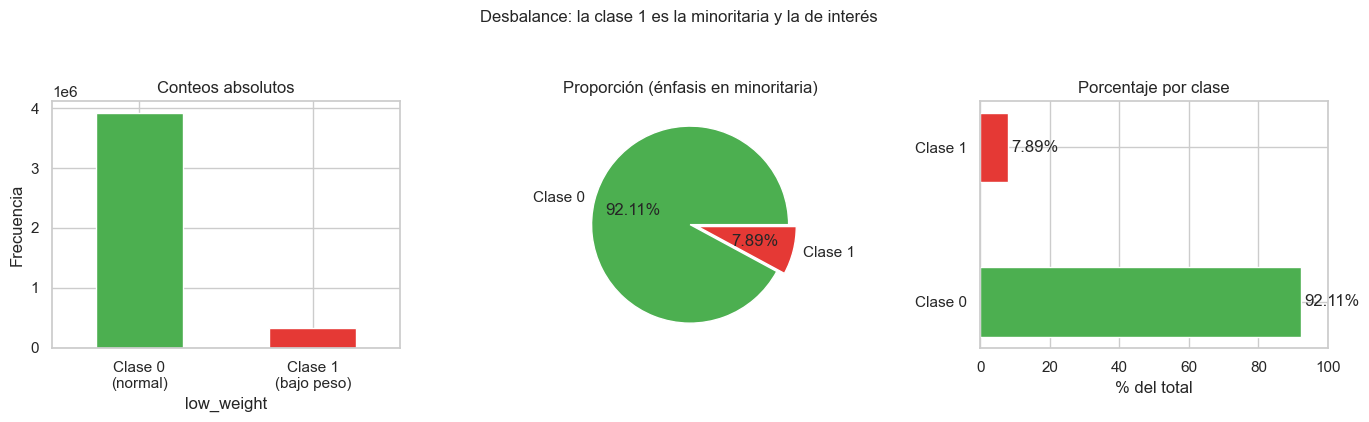

In [5]:
LABEL_POS = 1  # bajo peso: clase que nos interesa
vc = df_base["low_weight"].value_counts().sort_index()
n0, n1 = vc.get(0, 0), vc.get(1, 0)
N = n0 + n1
ir = n0 / n1 if n1 else np.inf  # ratio mayoritario / minoritario
print(f"Clase 0 (peso normal): {n0:,} ({n0/N:.2%})")
print(f"Clase 1 (bajo peso):   {n1:,} ({n1/N:.2%})  ← objetivo de detección")
print(f"Ratio desbalance (N0/N1): {ir:.1f}:1")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
vc.plot(kind="bar", ax=axes[0], color=["#4CAF50", "#E53935"], edgecolor="white")
axes[0].set_xticklabels(["Clase 0\n(normal)", "Clase 1\n(bajo peso)"], rotation=0)
axes[0].set_title("Conteos absolutos")
axes[0].set_ylabel("Frecuencia")

axes[1].pie([n0, n1], labels=["Clase 0", "Clase 1"], autopct="%1.2f%%", colors=["#4CAF50", "#E53935"], explode=(0, 0.08))
axes[1].set_title("Proporción (énfasis en minoritaria)")

axes[2].barh([0, 1], [n0 / N * 100, n1 / N * 100], color=["#4CAF50", "#E53935"], height=0.45)
axes[2].set_yticks([0, 1])
axes[2].set_yticklabels(["Clase 0", "Clase 1"])
axes[2].set_xlabel("% del total")
axes[2].set_title("Porcentaje por clase")
axes[2].set_xlim(0, 100)
for i, p in enumerate([n0 / N * 100, n1 / N * 100]):
    axes[2].text(p + 1, i, f"{p:.2f}%", va="center")
plt.suptitle("Desbalance: la clase 1 es la minoritaria y la de interés", y=1.05, fontsize=12)
plt.tight_layout()
plt.show()

## 4. Exploración: faltantes por variable

**Qué mirar:** porcentaje de NA ordenado de mayor a menor. Johnny documenta explícitamente esto antes de modelar.

**Lectura unificada (Edgar + otros):** si tabaco/alcohol/raza tienen ~el mismo % de nulos, es **missingness estructural** por diseño del reporte, no MCAR aleatorio. Imputar todo a “False” distorsiona la señal.

In [6]:
feat_cols = [c for c in df_base.columns if c not in (TARGET, "low_weight")]
miss = (df_base[feat_cols].isna().mean() * 100).sort_values(ascending=False)
miss = miss[miss > 0]
display(miss.to_frame("missing_%")) if len(miss) else print("Sin NAs en features listadas.")

,missing_%
drinks_per_week,100.0000
cigarettes_per_day,96.6676
mother_race,68.4441
father_race,68.4441
cigarette_use,65.0091
alcohol_use,65.0091
weight_gain_pounds,2.2293
ever_born,0.6058
gestation_weeks,0.1140


## 5. Muestra para gráficos (opcional)

Sobre millones de filas, histogramas completos son lentos. **Johnny** usa muestreo para EDA; el análisis de medias/correlaciones puede hacerse sobre todo el dataset si la memoria lo permite.

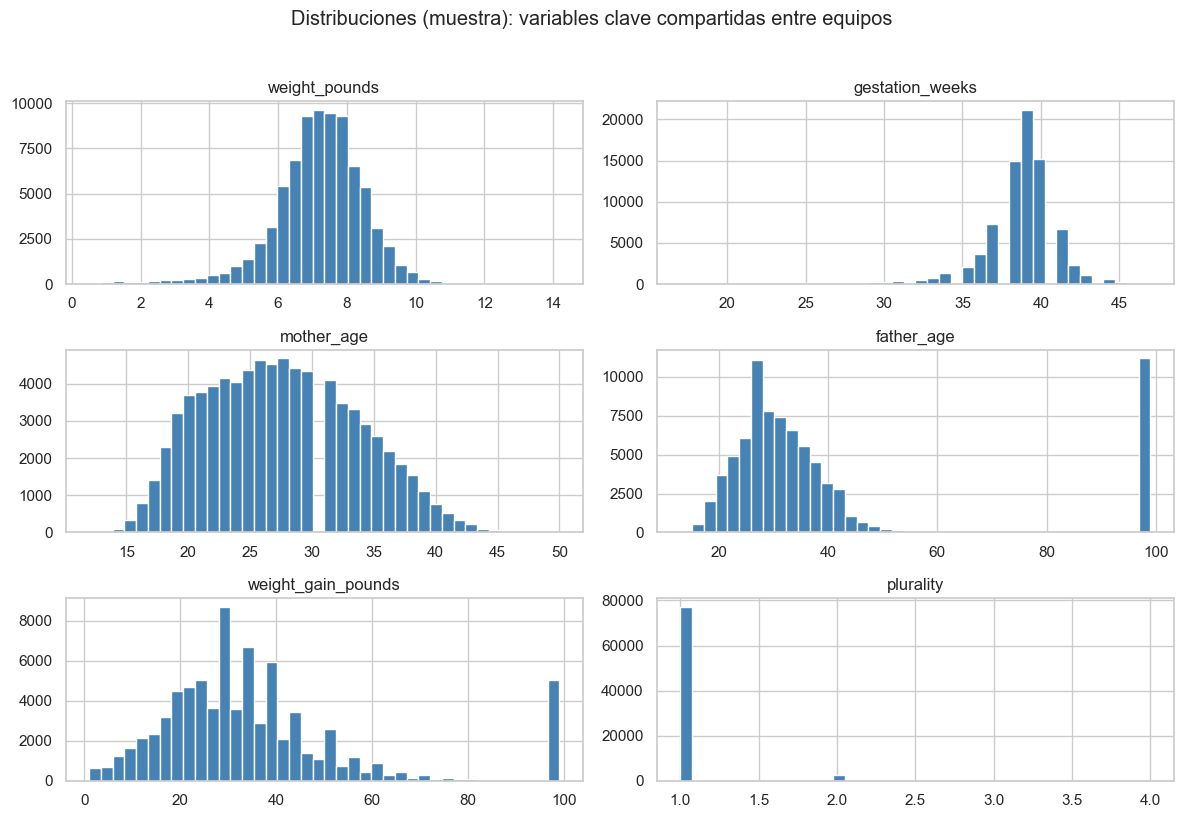

In [7]:
N_PLOT = 80_000
if len(df_base) > N_PLOT:
    plot_df = df_base.sample(n=N_PLOT, random_state=RNG)
else:
    plot_df = df_base

numeric_plot = [c for c in ["weight_pounds", "gestation_weeks", "mother_age", "father_age", "weight_gain_pounds", "plurality"] if c in plot_df.columns]
plot_df[numeric_plot].hist(bins=40, figsize=(12, 8), color="steelblue", edgecolor="white")
plt.suptitle("Distribuciones (muestra): variables clave compartidas entre equipos", y=1.02)
plt.tight_layout()
plt.show()

### 5.1 Más gráficas de exploración (separando clase 0 y clase 1)

Con **desbalance**, conviene ver si las distribuciones de cada predictor **difieren** entre bebés con bajo peso (`low_weight` = 1) y el resto. Aquí: **boxplots**, **violines**, **KDE** y, si hay columnas categóricas/booleanas disponibles, **proporciones por clase**.

Usamos la misma muestra `plot_df` que arriba para mantener el notebook ágil.

C:\Users\jhonn\AppData\Local\Temp\ipykernel_23408\1416756.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="grupo_peso", y=col, ax=ax, palette=["#4CAF50", "#E53935"])
C:\Users\jhonn\AppData\Local\Temp\ipykernel_23408\1416756.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="grupo_peso", y=col, ax=ax, palette=["#4CAF50", "#E53935"])
C:\Users\jhonn\AppData\Local\Temp\ipykernel_23408\1416756.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="grupo_peso", y=col, ax=ax, palette=["#4CAF50"

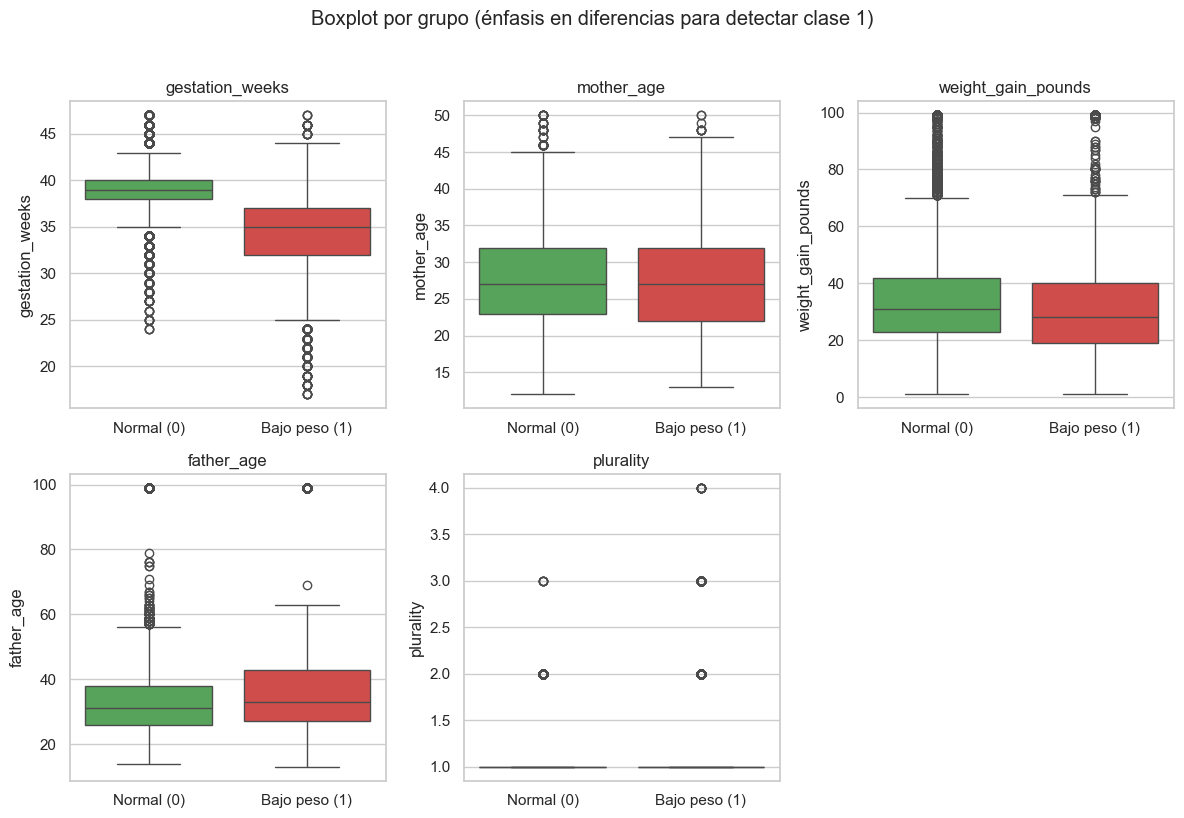

C:\Users\jhonn\AppData\Local\Temp\ipykernel_23408\1416756.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x="grupo_peso", y=col, ax=ax, palette=["#4CAF50", "#E53935"], inner="quartile")
C:\Users\jhonn\AppData\Local\Temp\ipykernel_23408\1416756.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x="grupo_peso", y=col, ax=ax, palette=["#4CAF50", "#E53935"], inner="quartile")
C:\Users\jhonn\AppData\Local\Temp\ipykernel_23408\1416756.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x="

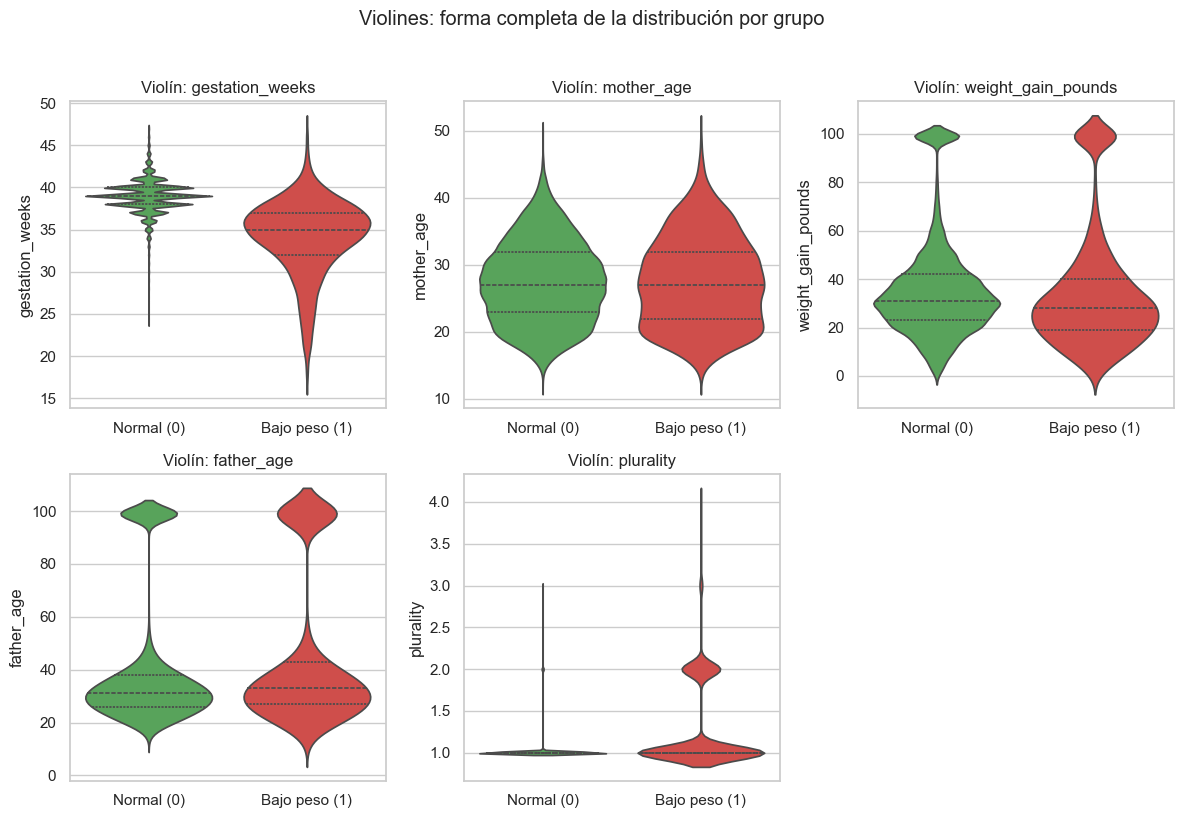

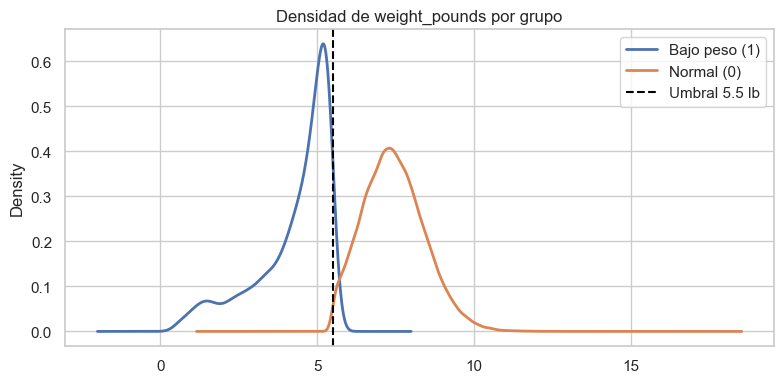

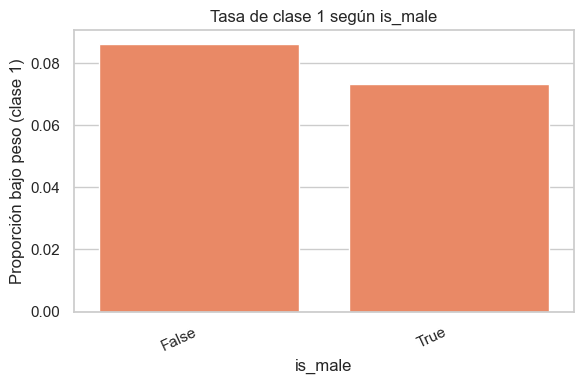

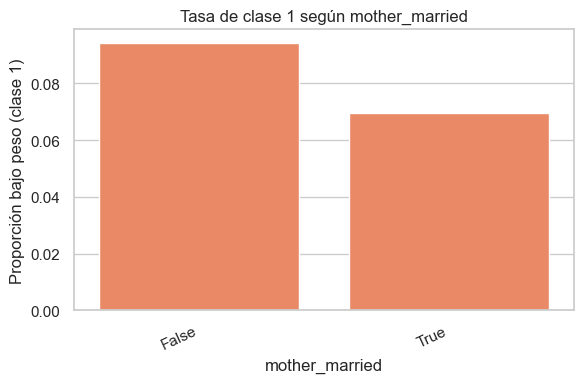

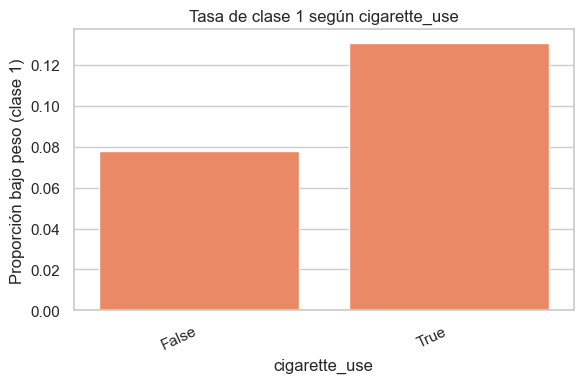

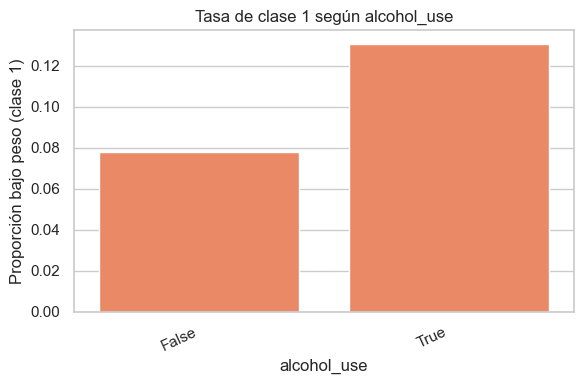

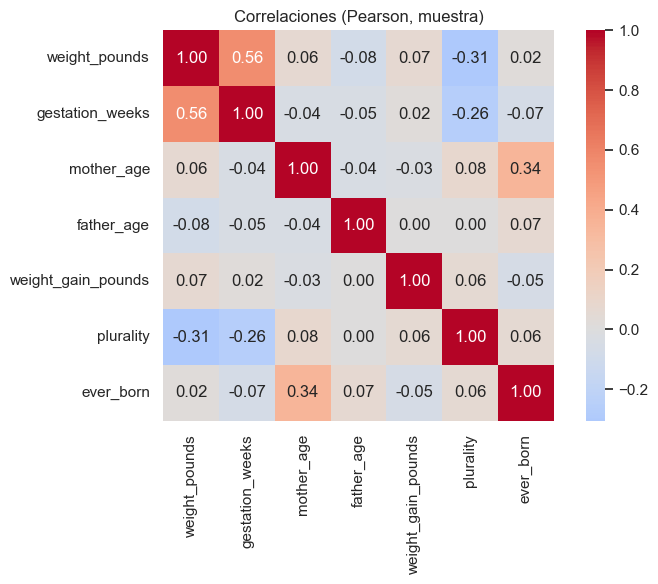

In [8]:
# Asegurar columna de etiqueta legible
plot_df = plot_df.copy()
plot_df["grupo_peso"] = plot_df["low_weight"].map({0: "Normal (0)", 1: "Bajo peso (1)"})

box_cols = [c for c in ["gestation_weeks", "mother_age", "weight_gain_pounds", "father_age", "plurality"] if c in plot_df.columns]
if box_cols:
    n = len(box_cols)
    fig, axes = plt.subplots(2, (n + 1) // 2, figsize=(4 * max(2, (n + 1) // 2), 8))
    axes = np.atleast_1d(axes).ravel()
    for ax, col in zip(axes, box_cols):
        sns.boxplot(data=plot_df, x="grupo_peso", y=col, ax=ax, palette=["#4CAF50", "#E53935"])
        ax.set_title(col)
        ax.set_xlabel("")
    for j in range(len(box_cols), len(axes)):
        axes[j].set_visible(False)
    plt.suptitle("Boxplot por grupo (énfasis en diferencias para detectar clase 1)", y=1.02)
    plt.tight_layout()
    plt.show()

if box_cols:
    fig, axes = plt.subplots(2, (len(box_cols) + 1) // 2, figsize=(4 * max(2, (len(box_cols) + 1) // 2), 8))
    axes = np.atleast_1d(axes).ravel()
    for ax, col in zip(axes, box_cols):
        sns.violinplot(data=plot_df, x="grupo_peso", y=col, ax=ax, palette=["#4CAF50", "#E53935"], inner="quartile")
        ax.set_title(f"Violín: {col}")
        ax.set_xlabel("")
    for j in range(len(box_cols), len(axes)):
        axes[j].set_visible(False)
    plt.suptitle("Violines: forma completa de la distribución por grupo", y=1.02)
    plt.tight_layout()
    plt.show()

# KDE del peso (continuo) coloreado por clase — útil para ver solapamiento
if "weight_pounds" in plot_df.columns:
    fig, ax = plt.subplots(figsize=(8, 4))
    for lab, sub in plot_df.groupby("grupo_peso"):
        sub["weight_pounds"].dropna().plot(kind="kde", ax=ax, label=lab, linewidth=2)
    ax.axvline(THRESHOLD_LB, color="black", linestyle="--", label=f"Umbral {THRESHOLD_LB} lb")
    ax.set_title("Densidad de weight_pounds por grupo")
    ax.legend()
    plt.tight_layout()
    plt.show()

# Variables categóricas / booleanas: tasa de bajo peso dentro de cada categoría
cat_cols = [c for c in ["is_male", "mother_married", "cigarette_use", "alcohol_use"] if c in plot_df.columns]
for col in cat_cols:
    tmp = plot_df[[col, "low_weight"]].dropna()
    if tmp.empty:
        continue
    rate = tmp.groupby(col, dropna=False)["low_weight"].agg(["mean", "count"]).reset_index()
    rate = rate.rename(columns={"mean": "tasa_clase_1", "count": "n"})
    fig, ax = plt.subplots(figsize=(max(6, 0.4 * len(rate)), 4))
    rate["_cat"] = rate[col].astype(str)
    sns.barplot(data=rate, x="_cat", y="tasa_clase_1", ax=ax, color="coral")
    ax.set_ylabel("Proporción bajo peso (clase 1)")
    ax.set_xlabel(col)
    ax.set_title(f"Tasa de clase 1 según {col}")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.show()

# Matriz de correlación solo numéricas (muestra)
num_for_heat = [c for c in ["weight_pounds", "gestation_weeks", "mother_age", "father_age", "weight_gain_pounds", "plurality", "ever_born"] if c in plot_df.columns]
if len(num_for_heat) >= 2:
    cm = plot_df[num_for_heat].corr(numeric_only=True)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
    plt.title("Correlaciones (Pearson, muestra)")
    plt.tight_layout()
    plt.show()

## 6. Correlación con `weight_pounds` (variables numéricas)

**Camilo** destaca que **`gestation_weeks`** lidera la correlación positiva con el peso. **Juan D** muestra correlaciones negativas fuertes para **`riesgo_prematuro`** y **`multiplo`** una vez creadas las dummies de riesgo.

Aquí calculamos Pearson sobre columnas numéricas **antes** del FE extendido, para una línea base comparable.

Correlación Pearson con weight_pounds (orden descendente):


,corr
gestation_weeks,0.5469
weight_gain_pounds,0.0758
mother_age,0.0641
ever_born,0.0212
cigarettes_per_day,-0.0231
mother_race,-0.0300
father_age,-0.0803
father_race,-0.1035
plurality,-0.3073
drinks_per_week,NaN


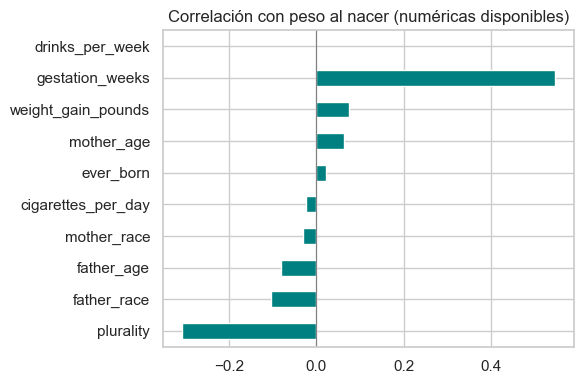

In [9]:
num_cols = df_base.select_dtypes(include=[np.number]).columns.tolist()
if TARGET in num_cols:
    num_cols.remove(TARGET)
if "low_weight" in num_cols:
    num_cols.remove("low_weight")

corr_y = df_base[num_cols + [TARGET]].corr()[TARGET].drop(TARGET).sort_values(ascending=False)
print("Correlación Pearson con weight_pounds (orden descendente):")
display(corr_y.to_frame("corr"))

plt.figure(figsize=(6, max(4, 0.35 * len(corr_y))))
corr_y.sort_values().plot(kind="barh", color="teal")
plt.axvline(0, color="gray", linewidth=0.8)
plt.title("Correlación con peso al nacer (numéricas disponibles)")
plt.tight_layout()
plt.show()

## 7. Ingeniería de características — Parte A: indicadores de reporte (Edgar)

| Nueva variable | Qué codifica |
|----------------|--------------|
| `cigarette_reported` | 1 si `cigarette_use` no es nulo; 0 si no hubo reporte. |
| `alcohol_reported` | Igual para alcohol. |
| `race_reported` | 1 si hay `mother_race` (proxy de que raza fue capturada). |
| `weight_gain_reported` | 1 si hay `weight_gain_pounds`. Edgar señala que el NA de ganancia **sí discrimina** riesgo de bajo peso (~diferencia de puntos porcentuales entre grupos). |

**Reglas deterministas (cuando existan las columnas):**
- Si `cigarette_use == False` y `cigarettes_per_day` es NA → **0** cigarrillos.
- Análogo para `alcohol_use` y `drinks_per_week` si trabajaras con esa columna.

Esto evita imputar masivamente con la moda y confundir “no consumo” con “no reportado”.

In [10]:
df_fe = df_base.copy()

if "cigarette_use" in df_fe.columns:
    df_fe["cigarette_reported"] = df_fe["cigarette_use"].notna().astype(np.int8)
if "alcohol_use" in df_fe.columns:
    df_fe["alcohol_reported"] = df_fe["alcohol_use"].notna().astype(np.int8)
if "mother_race" in df_fe.columns:
    df_fe["race_reported"] = df_fe["mother_race"].notna().astype(np.int8)
if "weight_gain_pounds" in df_fe.columns:
    df_fe["weight_gain_reported"] = df_fe["weight_gain_pounds"].notna().astype(np.int8)

if "cigarette_use" in df_fe.columns and "cigarettes_per_day" in df_fe.columns:
    mask = (df_fe["cigarette_use"] == False) & (df_fe["cigarettes_per_day"].isna())
    df_fe.loc[mask, "cigarettes_per_day"] = 0

if "alcohol_use" in df_fe.columns and "drinks_per_week" in df_fe.columns:
    mask = (df_fe["alcohol_use"] == False) & (df_fe["drinks_per_week"].isna())
    df_fe.loc[mask, "drinks_per_week"] = 0

report_cols = [c for c in ["cigarette_reported", "alcohol_reported", "race_reported", "weight_gain_reported"] if c in df_fe.columns]
if report_cols:
    display(df_fe[report_cols].mean().to_frame("P(dato reportado)"))

,P(dato reportado)
cigarette_reported,0.3499
alcohol_reported,0.3499
race_reported,0.3156
weight_gain_reported,0.9777


## 8. Ingeniería de características — Parte B: riesgo clínico y social (Juan D)

Estas variables son **binarias interpretables**; en el notebook de Juan D aparecen correlaciones con el peso (p. ej. prematuridad **~ -0.46**, múltiples **~ -0.31**).

| Variable | Definición | Por qué importa |
|----------|------------|-----------------|
| `riesgo_prematuro` | `gestation_weeks` < 37 | Prematuridad clínica. |
| `multiplo` | `plurality` > 1 | Embarazos múltiples → menor peso fetal medio. |
| `madre_muy_joven` | `mother_age` < 20 | Eje de riesgo perinatal en literatura. |
| `madre_mayor` | `mother_age` >= 35 | Otro polo de riesgo. |
| `ganancia_baja_peso` | `weight_gain_pounds` < 15 (lb) | Umbral operativo usado en ese trabajo; sensible a NA (solo donde hay dato). |
| `primigesta` | `ever_born` == 1 | Primigesta aproximada; **validar** definición de `ever_born` en el diccionario de datos. |
| `riesgo_social` | `mother_married` == 0 y `mother_age` < 20 | Proxy muy simplificado de vulnerabilidad; útil como feature, no como etiqueta social. |

**Nota:** si `gestation_weeks` o `weight_gain_pounds` son NaN, las comparaciones dan False salvo que uses `fillna` antes; para `ganancia_baja_peso` suele imputarse o exigir dato (Camilo imputa gestación y ganancia con mediana en su flujo).

In [11]:
if "gestation_weeks" in df_fe.columns:
    df_fe["riesgo_prematuro"] = (df_fe["gestation_weeks"] < 37).astype(np.int8)
if "plurality" in df_fe.columns:
    df_fe["multiplo"] = (df_fe["plurality"] > 1).astype(np.int8)
if "mother_age" in df_fe.columns:
    df_fe["madre_muy_joven"] = (df_fe["mother_age"] < 20).astype(np.int8)
    df_fe["madre_mayor"] = (df_fe["mother_age"] >= 35).astype(np.int8)
if "weight_gain_pounds" in df_fe.columns:
    df_fe["ganancia_baja_peso"] = (df_fe["weight_gain_pounds"] < 15).astype(np.int8)
    df_fe.loc[df_fe["weight_gain_pounds"].isna(), "ganancia_baja_peso"] = np.nan
if "ever_born" in df_fe.columns:
    df_fe["primigesta"] = (df_fe["ever_born"] == 1).astype(np.int8)
if "mother_married" in df_fe.columns and "mother_age" in df_fe.columns:
    mm = df_fe["mother_married"].astype("boolean")
    df_fe["riesgo_social"] = ((mm == False) & (df_fe["mother_age"] < 20)).astype(np.int8)

risk_cols = [c for c in ["riesgo_prematuro", "multiplo", "madre_muy_joven", "madre_mayor", "ganancia_baja_peso", "primigesta", "riesgo_social"] if c in df_fe.columns]
if risk_cols:
    display(df_fe[risk_cols].describe().T[["mean", "std"]])

,mean,std
riesgo_prematuro,0.1228,0.3282
multiplo,0.0341,0.1814
madre_muy_joven,0.1037,0.3048
madre_mayor,0.1419,0.3489
ganancia_baja_peso,0.0905,0.2869
primigesta,0.4012,0.4901
riesgo_social,0.0900,0.2862


## 9. Correlación de las nuevas features con el peso

Comprobamos que las construcciones capturan señal en la dirección esperada (negativa para factores de riesgo que reducen peso).

In [12]:
_risk_names = ["riesgo_prematuro", "multiplo", "madre_muy_joven", "madre_mayor", "ganancia_baja_peso", "primigesta", "riesgo_social"]
new_cols = [c for c in df_fe.columns if c.endswith("_reported") or c in _risk_names]
if new_cols:
    c2 = df_fe[new_cols + [TARGET]].corr(numeric_only=True)[TARGET].drop(TARGET).sort_values()
    display(c2.to_frame("corr_con_peso"))

,corr_con_peso
riesgo_prematuro,-0.4632
multiplo,-0.3052
ganancia_baja_peso,-0.0932
riesgo_social,-0.0627
madre_muy_joven,-0.0623
primigesta,-0.0453
race_reported,-0.0093
cigarette_reported,-0.0031
alcohol_reported,-0.0031
madre_mayor,0.0130


## 10. Perfil bajo peso vs normal (Camilo / Johnny)

**Camilo** compara medias de `gestation_weeks`, `mother_age`, `weight_gain_pounds` entre categorías de peso; concluye que la edad materna a veces **casi no separa** las medias globales, mientras gestación y ganancia sí mueven el perfil.

Replicamos una tabla compacta.

In [13]:
prof_cols = [c for c in ["gestation_weeks", "mother_age", "weight_gain_pounds"] if c in df_fe.columns]
if prof_cols:
    tab = df_fe.groupby("low_weight")[prof_cols].mean().round(2)
    tab.index = tab.index.map({0: ">= 5.5 lb", 1: "< 5.5 lb (bajo peso)"})
    display(tab)

,gestation_weeks,mother_age,weight_gain_pounds
low_weight,,,
>= 5.5 lb,38.9400,27.4100,35.7700
< 5.5 lb (bajo peso),34.2800,27.4400,34.1100


## 11. Outliers y valores centinela (Camilo / Santiago)

- **Rangos biológicos plausibles** (Camilo): `weight_pounds` en [1, 14], `gestation_weeks` en [24, 45].
- **IQR** en `mother_age` y `weight_gain_pounds` para recortar colas extremas.
- **99** como edad o cantidad “desconocida” en algunos campos: Santiago sustituye por mediana **ajustada en train** para no filtrar test con información del futuro.

La celda siguiente **no filtra** por defecto: solo define funciones reutilizables. Descomenta las llamadas si quieres aplicar los cortes en un pipeline exploratorio.

In [14]:
def clip_bio(df, col_weight="weight_pounds", col_gest="gestation_weeks"):
    out = df.copy()
    if col_weight in out.columns:
        out = out[(out[col_weight] >= 1) & (out[col_weight] <= 14)]
    if col_gest in out.columns:
        out = out[(out[col_gest] >= 24) & (out[col_gest] <= 45)]
    return out


def drop_iqr(df, col, k=1.5):
    s = df[col].dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - k * iqr, q3 + k * iqr
    return df[(df[col].isna()) | ((df[col] >= lo) & (df[col] <= hi))]


# Ejemplo (descomentar para usar):
# df_fe = clip_bio(df_fe)
# df_fe = drop_iqr(df_fe, "mother_age")
# df_fe = drop_iqr(df_fe, "weight_gain_pounds")
print("Funciones clip_bio y drop_iqr definidas. Filtrado manual desactivado.")

Funciones clip_bio y drop_iqr definidas. Filtrado manual desactivado.


## 12. Lista sugerida para modelado (X / y)

**Numéricas base** (según existan): `plurality`, `mother_age`, `gestation_weeks`, `weight_gain_pounds`, `father_age`, `cigarettes_per_day`, `ever_born`.

**Categóricas / bool** (Emmanuel convierte bool a 0/1): `is_male`, `mother_married`, `mother_race`, `father_race`, `cigarette_use`, `alcohol_use`.

**Añadidas en este notebook**: indicadores `*_reported` + riesgos `riesgo_*`, `multiplo`, etc.

**Preprocesamiento típico (Edgar)**: `ColumnTransformer` con mediana + escalado en numéricas, One-Hot en razas, imputación en booleanos.

Para **evitar leakage**, define el `train_test_split` **antes** de imputar mediana/IQR y **ajusta** transformadores solo sobre train (Santiago, Edgar).

In [15]:
exclude_y = {TARGET, "low_weight"}
X_cols = [c for c in df_fe.columns if c not in exclude_y]
print(f"Total features candidatas: {len(X_cols)}")
print(X_cols)

Total features candidatas: 25
['is_male', 'plurality', 'mother_race', 'mother_age', 'gestation_weeks', 'mother_married', 'cigarette_use', 'cigarettes_per_day', 'alcohol_use', 'drinks_per_week', 'weight_gain_pounds', 'ever_born', 'father_race', 'father_age', 'cigarette_reported', 'alcohol_reported', 'race_reported', 'weight_gain_reported', 'riesgo_prematuro', 'multiplo', 'madre_muy_joven', 'madre_mayor', 'ganancia_baja_peso', 'primigesta', 'riesgo_social']


## 13. Resumen ejecutivo

1. **`gestation_weeks`** es el eje dominante del EDA multivariado hacia `weight_pounds`; las features de **prematuridad** y **múltiple** lo refuerzan como dominio.
2. **Desbalance**: la **clase 1** (bajo peso) es minoritaria; no uses solo accuracy: mira **recall/precision/F1/PR-AUC** y estrategias de muestreo o `class_weight` al entrenar.
3. Los **faltantes masivos** en hábitos y raza deben modelarse como **información de no-reporte**, no como valores imputados ciegamente.
4. Las **features de riesgo** (Juan D) comprimen edad, gestación y sociodemografía en indicadores interpretables y correlacionados con el peso.
5. **Outliers** y **99**: combinar reglas clínicas con estadística, siempre **fit en train**.
6. **`ever_born` / `primigesta`**: decidir según definición de variable; si hay duda de leakage, excluir del modelo final.

Este notebook es la base documentada; el entrenamiento de modelos puede seguir los pipelines ya presentes en `Edgar`, `Camilo`, `Johnny` o `Santiago` usando `df_fe` exportado o las mismas transformaciones en producción.

## Parte 2 — Modelado predictivo

Los modelos usan el mismo **`df_fe`** construido en la Parte 1 (no se vuelve a leer el CSV). Si el dataset es muy grande, se toman **muestras** `N_SAMPLE_REG` y `N_SAMPLE_CLF` en la siguiente celda.

Ejecuta las celdas **en orden** desde el inicio del notebook.


In [16]:
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNetCV, LinearRegression, LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import (
    RandomForestRegressor,
    RandomForestClassifier,
    BaggingClassifier,
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVR, LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    RocCurveDisplay,
    PrecisionRecallDisplay,
    accuracy_score,
    average_precision_score,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
)
from sklearn.base import clone

try:
    from xgboost import XGBRegressor, XGBClassifier
except ImportError:
    XGBRegressor = XGBClassifier = None

try:
    from lightgbm import LGBMRegressor, LGBMClassifier
except ImportError:
    LGBMRegressor = LGBMClassifier = None

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    try:
        plt.style.use("seaborn-whitegrid")
    except OSError:
        pass

# Tamaño de muestra para entrenar (ajusta si tienes poca RAM o quieres más datos)
N_SAMPLE_REG = 200_000
N_SAMPLE_CLF = 200_000


In [17]:
# Muestras y funciones de evaluación (reutiliza df_fe, TARGET y RNG del EDA)
from sklearn.model_selection import train_test_split as _tts


def get_X_y(df, mode):
    drop_y = {TARGET, "low_weight"}
    X = df.drop(columns=[c for c in drop_y if c in df.columns], errors="ignore")
    if mode == "regression":
        y = df[TARGET]
    else:
        y = df["low_weight"]
    return X, y


def train_val_test_split(
    X,
    y,
    test_size=0.15,
    val_size=0.15,
    stratify=None,
    random_state=42,
):
    from sklearn.model_selection import train_test_split as tts

    X_temp, X_test, y_temp, y_test = tts(
        X,
        y,
        test_size=test_size,
        stratify=stratify,
        random_state=random_state,
    )
    val_rel = val_size / (1.0 - test_size)
    strat2 = y_temp if stratify is not None else None
    X_train, X_val, y_train, y_val = tts(
        X_temp,
        y_temp,
        test_size=val_rel,
        stratify=strat2,
        random_state=random_state,
    )
    return X_train, X_val, X_test, y_train, y_val, y_test


def detect_feature_types(X):
    num_cols = []
    cat_cols = []
    for c in X.columns:
        s = X[c]
        dt = s.dtype
        if pd.api.types.is_bool_dtype(dt) or str(dt) == "boolean":
            cat_cols.append(c)
        elif pd.api.types.is_numeric_dtype(dt):
            num_cols.append(c)
        else:
            cat_cols.append(c)
    return num_cols, cat_cols


def regression_scores(y_true, y_pred):
    return {
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "R2": float(r2_score(y_true, y_pred)),
    }


def classification_scores(y_true, y_pred, y_proba=None):
    out = {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
    }
    if y_proba is not None:
        try:
            out["roc_auc"] = float(roc_auc_score(y_true, y_proba))
        except ValueError:
            out["roc_auc"] = np.nan
        try:
            out["pr_auc"] = float(average_precision_score(y_true, y_proba))
        except ValueError:
            out["pr_auc"] = np.nan
    return out


_df = df_fe.copy()
if len(_df) > N_SAMPLE_REG:
    df_reg = _df.sample(n=N_SAMPLE_REG, random_state=RNG).reset_index(drop=True)
else:
    df_reg = _df.copy()
if len(_df) > N_SAMPLE_CLF:
    df_clf, _ = _tts(
        _df,
        train_size=N_SAMPLE_CLF,
        stratify=_df["low_weight"],
        random_state=RNG,
    )
    df_clf = df_clf.reset_index(drop=True)
else:
    df_clf = _df.copy()

Xr, yr = get_X_y(df_reg, "regression")
Xc, yc = get_X_y(df_clf, "classification")
num_r, cat_r = detect_feature_types(Xr)
num_c, cat_c = detect_feature_types(Xc)
print("Regresión — filas:", len(yr), "| num:", len(num_r), "cat:", len(cat_r))
print("Clasificación — filas:", len(yc), "| num:", len(num_c), "cat:", len(cat_c))
print("Proporción low_weight (muestra clf):", yc.mean())


Regresión — filas: 200000 | num: 21 cat: 4
Clasificación — filas: 200000 | num: 21 cat: 4
Proporción low_weight (muestra clf): 0.07885


In [18]:
def _one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def make_prep_linear(num_cols, cat_cols):
    transformers = []
    if num_cols:
        transformers.append(
            (
                "num",
                Pipeline(
                    [
                        ("imputer", SimpleImputer(strategy="median")),
                        ("scaler", StandardScaler()),
                    ]
                ),
                num_cols,
            )
        )
    if cat_cols:
        transformers.append(
            (
                "cat",
                Pipeline(
                    [
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        ("ohe", _one_hot_encoder()),
                    ]
                ),
                cat_cols,
            )
        )
    return ColumnTransformer(transformers, remainder="drop")


def make_prep_tree(num_cols, cat_cols):
    transformers = []
    if num_cols:
        transformers.append(("num", SimpleImputer(strategy="median"), num_cols))
    if cat_cols:
        transformers.append(
            (
                "cat",
                Pipeline(
                    [
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        ("ohe", _one_hot_encoder()),
                    ]
                ),
                cat_cols,
            )
        )
    return ColumnTransformer(transformers, remainder="drop")


def get_feature_names_safe(pipe, X_cols):
    prep = pipe.named_steps.get("prep") or pipe.named_steps.get("columntransformer")
    if prep is None:
        return [f"f{i}" for i in range(1000)]
    try:
        return list(prep.get_feature_names_out())
    except Exception:
        return [f"f{i}" for i in range(100)]


def plot_top_importance(names, values, title, ax=None, top=20):
    if ax is None:
        _, ax = plt.subplots(figsize=(8, max(4, top * 0.22)))
    order = np.argsort(np.abs(values))[-top:]
    ax.barh(np.array(names)[order], np.array(values)[order], color="steelblue")
    ax.set_title(title)
    ax.set_xlabel("Importancia / |coef.|")
    return ax


results_reg = []
results_clf = []


## Regresión (`weight_pounds`)


In [19]:
X_train_r, X_val_r, X_test_r, y_train_r, y_val_r, y_test_r = train_val_test_split(
    Xr, yr, test_size=0.15, val_size=0.15, stratify=None, random_state=RNG
)
prep_lin_r = make_prep_linear(num_r, cat_r)
prep_tree_r = make_prep_tree(num_r, cat_r)
print("Regresión — train/val/test:", len(y_train_r), len(y_val_r), len(y_test_r))


Regresión — train/val/test: 139999 30001 30000


### Modelo 1 — Regresión lineal (OLS)

Minimiza la suma de cuadrados de los errores; supone relación aproximadamente lineal entre features transformadas y el peso. Rápido e interpretable (coeficientes en escala estandarizada).


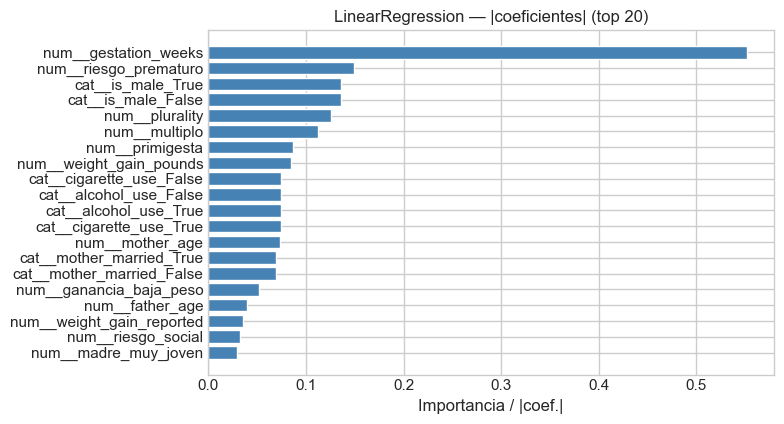

    RMSE    MAE     R2            modelo particion
0 1.0319 0.7991 0.3776  LinearRegression     train
1 1.0338 0.8020 0.3708  LinearRegression       val
2 1.0327 0.8012 0.3712  LinearRegression      test


In [20]:
name = "LinearRegression"
pipe = Pipeline([("prep", clone(prep_lin_r)), ("model", LinearRegression())])
pipe.fit(X_train_r, y_train_r)

for part, Xp, yp in [
    ("train", X_train_r, y_train_r),
    ("val", X_val_r, y_val_r),
    ("test", X_test_r, y_test_r),
]:
    pred = pipe.predict(Xp)
    m = regression_scores(yp, pred)
    m.update({"modelo": name, "particion": part})
    results_reg.append(m)

coef = pipe.named_steps["model"].coef_
fn = get_feature_names_safe(pipe, Xr.columns)
imp = np.abs(coef)[: len(fn)]
plot_top_importance(fn[: len(imp)], imp, f"{name} — |coeficientes| (top 20)", top=20)
plt.tight_layout()
plt.show()
print(pd.DataFrame(results_reg).query("modelo == @name"))


### Modelo 2 — Elastic Net (validación cruzada)

Combina penalización L1 (Lasso) y L2 (Ridge): selecciona variables y estabiliza frente a multicolinealidad. `ElasticNetCV` elige el balance y la fuerza de regularización por CV.


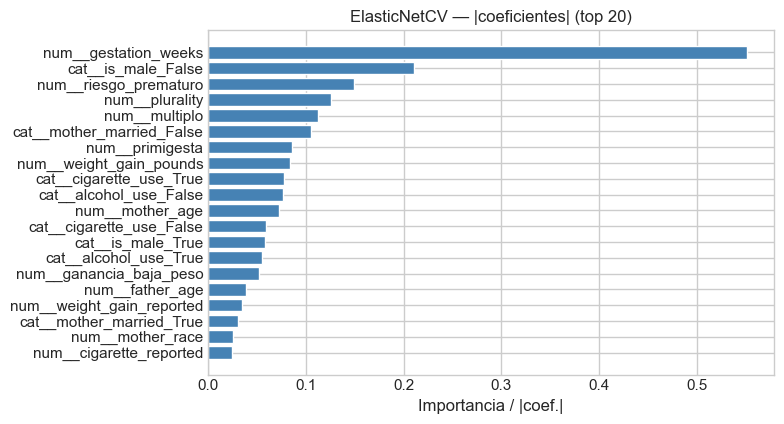

    RMSE    MAE     R2        modelo particion
3 1.0319 0.7991 0.3775  ElasticNetCV     train
4 1.0338 0.8019 0.3708  ElasticNetCV       val
5 1.0328 0.8012 0.3711  ElasticNetCV      test


In [21]:
name = "ElasticNetCV"
pipe = Pipeline(
    [
        ("prep", clone(prep_lin_r)),
        (
            "model",
            ElasticNetCV(l1_ratio=[0.1, 0.5, 0.9], cv=5, random_state=RNG, max_iter=5000),
        ),
    ]
)
pipe.fit(X_train_r, y_train_r)

for part, Xp, yp in [
    ("train", X_train_r, y_train_r),
    ("val", X_val_r, y_val_r),
    ("test", X_test_r, y_test_r),
]:
    pred = pipe.predict(Xp)
    m = regression_scores(yp, pred)
    m.update({"modelo": name, "particion": part})
    results_reg.append(m)

coef = np.abs(pipe.named_steps["model"].coef_)
fn = get_feature_names_safe(pipe, Xr.columns)
plot_top_importance(fn[: len(coef)], coef, f"{name} — |coeficientes| (top 20)", top=20)
plt.tight_layout()
plt.show()
print(pd.DataFrame(results_reg).query("modelo == @name"))


### Modelo 3 — Random Forest (regresión)

Ensamble de árboles con bootstrap de filas y subconjuntos de variables; captura no linealidades e interacciones. Métricas de importancia basadas en reducción de impureza.


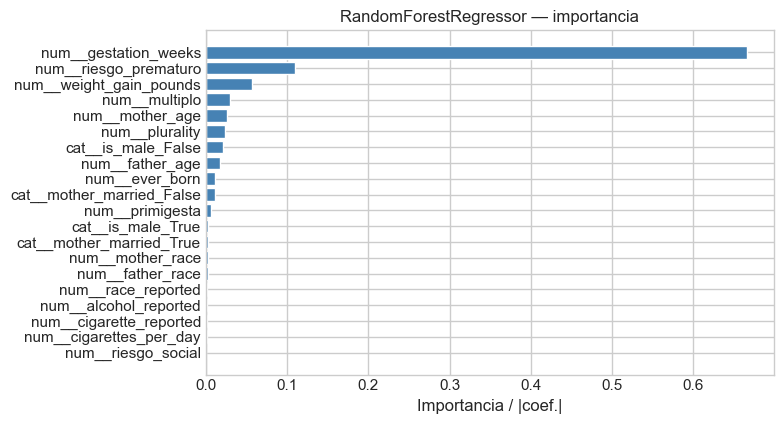

    RMSE    MAE     R2                 modelo particion
6 0.9670 0.7482 0.4534  RandomForestRegressor     train
7 0.9989 0.7742 0.4126  RandomForestRegressor       val
8 0.9981 0.7709 0.4126  RandomForestRegressor      test


In [22]:
name = "RandomForestRegressor"
pipe = Pipeline(
    [
        ("prep", clone(prep_tree_r)),
        (
            "model",
            RandomForestRegressor(
                n_estimators=80,
                max_depth=16,
                min_samples_leaf=50,
                random_state=RNG,
                n_jobs=-1,
            ),
        ),
    ]
)
pipe.fit(X_train_r, y_train_r)

for part, Xp, yp in [
    ("train", X_train_r, y_train_r),
    ("val", X_val_r, y_val_r),
    ("test", X_test_r, y_test_r),
]:
    pred = pipe.predict(Xp)
    m = regression_scores(yp, pred)
    m.update({"modelo": name, "particion": part})
    results_reg.append(m)

fn = get_feature_names_safe(pipe, Xr.columns)
imp = pipe.named_steps["model"].feature_importances_
plot_top_importance(fn[: len(imp)], imp, f"{name} — importancia", top=20)
plt.tight_layout()
plt.show()
print(pd.DataFrame(results_reg).query("modelo == @name"))


### Modelo 4 — XGBoost (regresión)

Gradient boosting con árboles: entrena secuencialmente corrigiendo residuos. Suele dar muy buen ajuste; requiere ajuste de hiperparámetros y control de sobreajuste.


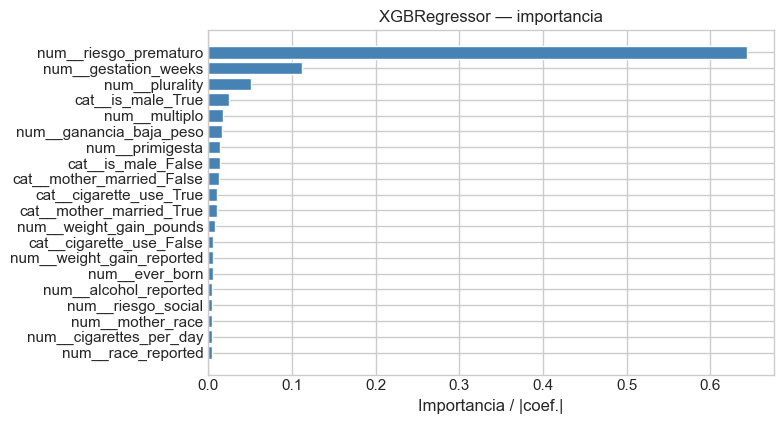

     RMSE    MAE     R2        modelo particion
9  0.9458 0.7329 0.4772  XGBRegressor     train
10 0.9933 0.7696 0.4191  XGBRegressor       val
11 0.9929 0.7660 0.4187  XGBRegressor      test


In [23]:
name = "XGBRegressor"
if XGBRegressor is None:
    print("xgboost no instalado; se omite.")
else:
    pipe = Pipeline(
        [
            ("prep", clone(prep_tree_r)),
            (
                "model",
                XGBRegressor(
                    n_estimators=120,
                    max_depth=8,
                    learning_rate=0.08,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    tree_method="hist",
                    random_state=RNG,
                    n_jobs=-1,
                ),
            ),
        ]
    )
    pipe.fit(X_train_r, y_train_r)
    for part, Xp, yp in [
        ("train", X_train_r, y_train_r),
        ("val", X_val_r, y_val_r),
        ("test", X_test_r, y_test_r),
    ]:
        pred = pipe.predict(Xp)
        m = regression_scores(yp, pred)
        m.update({"modelo": name, "particion": part})
        results_reg.append(m)
    fn = get_feature_names_safe(pipe, Xr.columns)
    imp = pipe.named_steps["model"].feature_importances_
    plot_top_importance(fn[: len(imp)], imp, f"{name} — importancia", top=20)
    plt.tight_layout()
    plt.show()
    print(pd.DataFrame(results_reg).query("modelo == @name"))


### Modelo 5 — LightGBM (regresión)

Boosting con crecimiento de hoja a hoja (leaf-wise), eficiente en tabulares grandes. Comportamiento similar a XGBoost con otro esquema de partición.


In [24]:
name = "LGBMRegressor"
if LGBMRegressor is None:
    print("lightgbm no instalado; se omite.")
else:
    pipe = Pipeline(
        [
            ("prep", clone(prep_tree_r)),
            (
                "model",
                LGBMRegressor(
                    n_estimators=200,
                    max_depth=-1,
                    learning_rate=0.05,
                    num_leaves=63,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    random_state=RNG,
                    n_jobs=-1,
                    verbose=-1,
                ),
            ),
        ]
    )
    pipe.fit(X_train_r, y_train_r)
    for part, Xp, yp in [
        ("train", X_train_r, y_train_r),
        ("val", X_val_r, y_val_r),
        ("test", X_test_r, y_test_r),
    ]:
        pred = pipe.predict(Xp)
        m = regression_scores(yp, pred)
        m.update({"modelo": name, "particion": part})
        results_reg.append(m)
    fn = get_feature_names_safe(pipe, Xr.columns)
    imp = pipe.named_steps["model"].feature_importances_
    plot_top_importance(fn[: len(imp)], imp, f"{name} — importancia", top=20)
    plt.tight_layout()
    plt.show()
    print(pd.DataFrame(results_reg).query("modelo == @name"))


lightgbm no instalado; se omite.


### Modelo 6 — Linear SVR

Versión lineal de máquinas de vectores de soporte para regresión: busca un tubo de tolerancia ε alrededor de la predicción y penaliza desviaciones. Útil como baseline no lineal suave con kernel lineal.


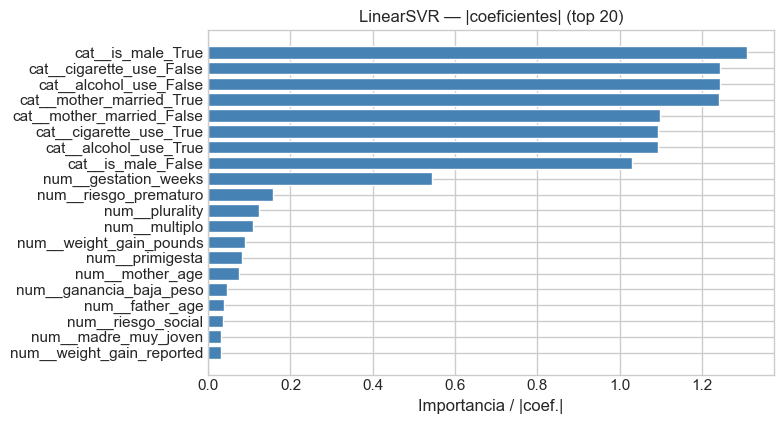

     RMSE    MAE     R2     modelo particion
12 1.0321 0.7989 0.3773  LinearSVR     train
13 1.0341 0.8018 0.3704  LinearSVR       val
14 1.0328 0.8008 0.3710  LinearSVR      test


In [25]:
name = "LinearSVR"
pipe = Pipeline(
    [
        ("prep", clone(prep_lin_r)),
        ("model", LinearSVR(C=1.0, max_iter=5000, random_state=RNG)),
    ]
)
pipe.fit(X_train_r, y_train_r)

for part, Xp, yp in [
    ("train", X_train_r, y_train_r),
    ("val", X_val_r, y_val_r),
    ("test", X_test_r, y_test_r),
]:
    pred = pipe.predict(Xp)
    m = regression_scores(yp, pred)
    m.update({"modelo": name, "particion": part})
    results_reg.append(m)

coef = np.abs(pipe.named_steps["model"].coef_.ravel())
fn = get_feature_names_safe(pipe, Xr.columns)
plot_top_importance(fn[: len(coef)], coef, f"{name} — |coeficientes| (top 20)", top=20)
plt.tight_layout()
plt.show()
print(pd.DataFrame(results_reg).query("modelo == @name"))


## Clasificación (objetivo: `low_weight` = 1 si peso < 5.5 lb)

Los modelos lineales usan `class_weight='balanced'` o calibración / `scale_pos_weight` para mitigar el desbalance a favor de la clase positiva (bajo peso).


In [26]:
X_train_c, X_val_c, X_test_c, y_train_c, y_val_c, y_test_c = train_val_test_split(
    Xc, yc, test_size=0.15, val_size=0.15, stratify=yc, random_state=RNG
)
prep_lin_c = make_prep_linear(num_c, cat_c)
prep_tree_c = make_prep_tree(num_c, cat_c)
spw = (y_train_c == 0).sum() / max(1, (y_train_c == 1).sum())
print("Clasificación — train/val/test:", len(y_train_c), len(y_val_c), len(y_test_c))
print("scale_pos_weight (≈ neg/pos):", spw)


Clasificación — train/val/test: 139999 30001 30000
scale_pos_weight (≈ neg/pos): 11.682217592173204


### Modelo 7 — Regresión logística

Modelo lineal en el espacio de log-odds; probabilidades bien calibradas si se cumplen supuestos. `class_weight='balanced'` repondera la clase minoritaria.


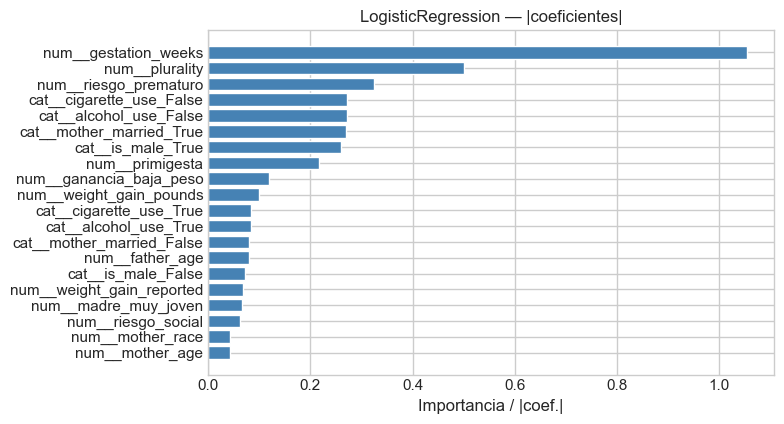

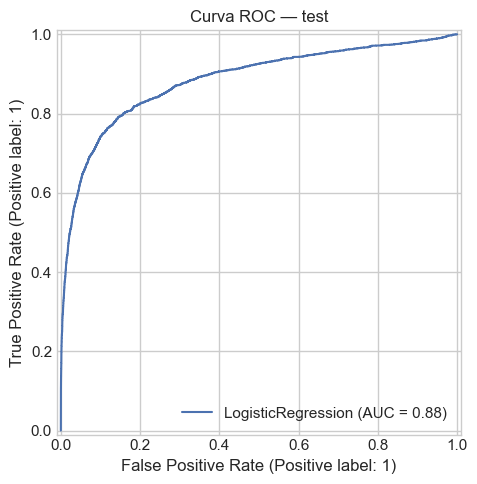

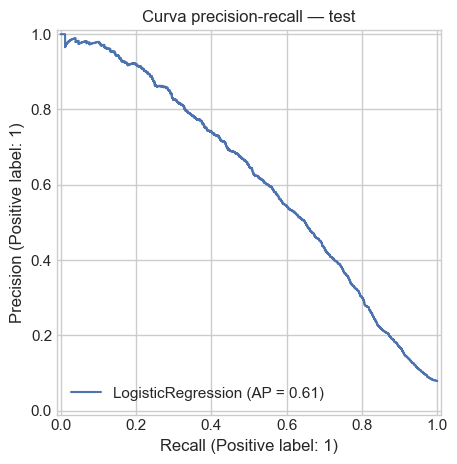

   accuracy  precision  recall     f1  roc_auc  pr_auc              modelo  \
0    0.8870     0.3876  0.7473 0.5104   0.8899  0.6181  LogisticRegression   
1    0.8842     0.3796  0.7384 0.5014   0.8851  0.6013  LogisticRegression   
2    0.8863     0.3853  0.7429 0.5074   0.8844  0.6090  LogisticRegression   

  particion  
0     train  
1       val  
2      test  


In [27]:
name = "LogisticRegression"
pipe = Pipeline(
    [
        ("prep", clone(prep_lin_c)),
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=RNG,
            ),
        ),
    ]
)
pipe.fit(X_train_c, y_train_c)

for part, Xp, yp in [
    ("train", X_train_c, y_train_c),
    ("val", X_val_c, y_val_c),
    ("test", X_test_c, y_test_c),
]:
    pred = pipe.predict(Xp)
    proba = pipe.predict_proba(Xp)[:, 1]
    m = classification_scores(yp, pred, proba)
    m.update({"modelo": name, "particion": part})
    results_clf.append(m)

fn = get_feature_names_safe(pipe, Xc.columns)
coef = np.abs(pipe.named_steps["model"].coef_.ravel())
plot_top_importance(fn[: len(coef)], coef, f"{name} — |coeficientes|", top=20)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test_c, pipe.predict_proba(X_test_c)[:, 1], ax=ax, name=name)
ax.set_title("Curva ROC — test")
plt.tight_layout()
plt.show()

disp = PrecisionRecallDisplay.from_predictions(y_test_c, pipe.predict_proba(X_test_c)[:, 1], name=name)
disp.ax_.set_title("Curva precision-recall — test")
plt.tight_layout()
plt.show()
print(pd.DataFrame(results_clf).query("modelo == @name"))


### Modelo 8 — SVM lineal + calibración (probabilidades)

`LinearSVC` no entrega probabilidades; `CalibratedClassifierCV` ajusta un calibrador (platt / isotónico) en CV para obtener `predict_proba` y curvas ROC.


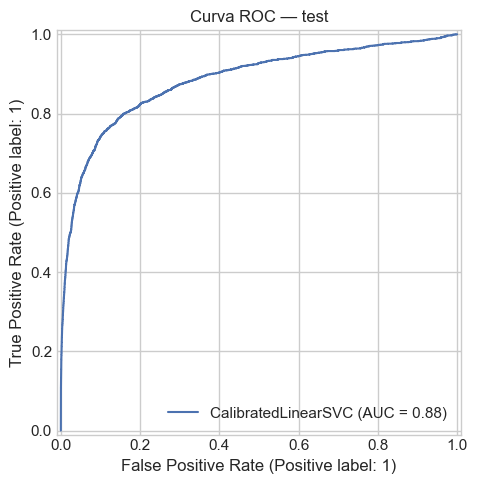

   accuracy  precision  recall     f1  roc_auc  pr_auc               modelo  \
3    0.9415     0.7472  0.3896 0.5122   0.8897  0.6140  CalibratedLinearSVC   
4    0.9401     0.7407  0.3707 0.4941   0.8855  0.5977  CalibratedLinearSVC   
5    0.9415     0.7598  0.3772 0.5041   0.8847  0.6063  CalibratedLinearSVC   

  particion  
3     train  
4       val  
5      test  


In [28]:
name = "CalibratedLinearSVC"
base = LinearSVC(class_weight="balanced", dual=False, max_iter=5000, random_state=RNG)
pipe = Pipeline(
    [
        ("prep", clone(prep_lin_c)),
        ("model", CalibratedClassifierCV(base, cv=3)),
    ]
)
pipe.fit(X_train_c, y_train_c)

for part, Xp, yp in [
    ("train", X_train_c, y_train_c),
    ("val", X_val_c, y_val_c),
    ("test", X_test_c, y_test_c),
]:
    pred = pipe.predict(Xp)
    proba = pipe.predict_proba(Xp)[:, 1]
    m = classification_scores(yp, pred, proba)
    m.update({"modelo": name, "particion": part})
    results_clf.append(m)

fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test_c, pipe.predict_proba(X_test_c)[:, 1], ax=ax, name=name)
ax.set_title("Curva ROC — test")
plt.tight_layout()
plt.show()
print(pd.DataFrame(results_clf).query("modelo == @name"))


### Modelo 9 — Random Forest (clasificación)

Misma idea que en regresión; voto mayoritario entre árboles. `class_weight='balanced'`.


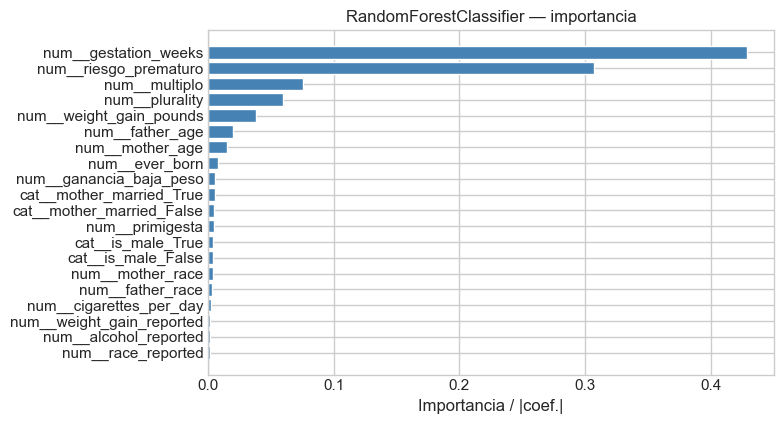

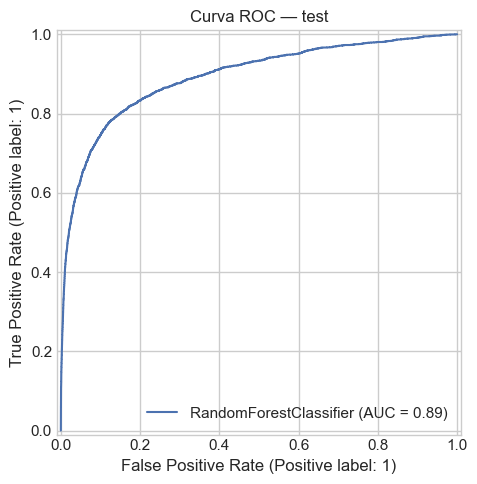

   accuracy  precision  recall     f1  roc_auc  pr_auc  \
6    0.8804     0.3763  0.7870 0.5092   0.9198  0.6406   
7    0.8755     0.3618  0.7566 0.4895   0.8895  0.5957   
8    0.8770     0.3661  0.7662 0.4954   0.8931  0.6108   

                   modelo particion  
6  RandomForestClassifier     train  
7  RandomForestClassifier       val  
8  RandomForestClassifier      test  


In [29]:
name = "RandomForestClassifier"
pipe = Pipeline(
    [
        ("prep", clone(prep_tree_c)),
        (
            "model",
            RandomForestClassifier(
                n_estimators=80,
                max_depth=16,
                min_samples_leaf=50,
                class_weight="balanced",
                random_state=RNG,
                n_jobs=-1,
            ),
        ),
    ]
)
pipe.fit(X_train_c, y_train_c)

for part, Xp, yp in [
    ("train", X_train_c, y_train_c),
    ("val", X_val_c, y_val_c),
    ("test", X_test_c, y_test_c),
]:
    pred = pipe.predict(Xp)
    proba = pipe.predict_proba(Xp)[:, 1]
    m = classification_scores(yp, pred, proba)
    m.update({"modelo": name, "particion": part})
    results_clf.append(m)

fn = get_feature_names_safe(pipe, Xc.columns)
imp = pipe.named_steps["model"].feature_importances_
plot_top_importance(fn[: len(imp)], imp, f"{name} — importancia", top=20)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test_c, pipe.predict_proba(X_test_c)[:, 1], ax=ax, name=name)
ax.set_title("Curva ROC — test")
plt.tight_layout()
plt.show()
print(pd.DataFrame(results_clf).query("modelo == @name"))


### Modelo 10 — Bagging (árbol de decisión)

Promedia predicciones de muchos árboles entrenados sobre submuestras bootstrap; reduce varianza respecto a un solo árbol.


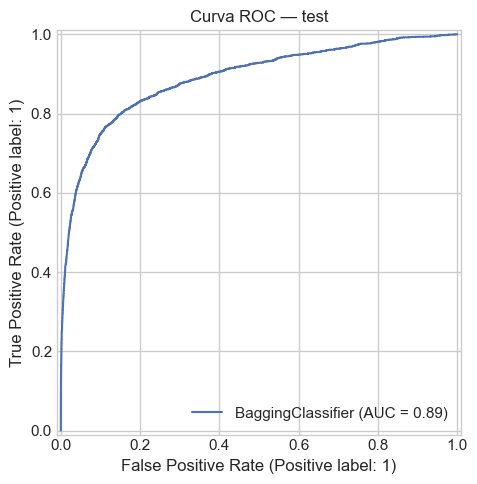

    accuracy  precision  recall     f1  roc_auc  pr_auc             modelo  \
9     0.8755     0.3666  0.7957 0.5020   0.9195  0.6526  BaggingClassifier   
10    0.8707     0.3524  0.7629 0.4821   0.8876  0.6104  BaggingClassifier   
11    0.8723     0.3566  0.7708 0.4876   0.8905  0.6219  BaggingClassifier   

   particion  
9      train  
10       val  
11      test  


In [30]:
name = "BaggingClassifier"
base = DecisionTreeClassifier(
    max_depth=12,
    min_samples_leaf=100,
    class_weight="balanced",
    random_state=RNG,
)
pipe = Pipeline(
    [
        ("prep", clone(prep_tree_c)),
        (
            "model",
            BaggingClassifier(
                estimator=base,
                n_estimators=30,
                random_state=RNG,
                n_jobs=-1,
            ),
        ),
    ]
)
pipe.fit(X_train_c, y_train_c)

for part, Xp, yp in [
    ("train", X_train_c, y_train_c),
    ("val", X_val_c, y_val_c),
    ("test", X_test_c, y_test_c),
]:
    pred = pipe.predict(Xp)
    proba = pipe.predict_proba(Xp)[:, 1]
    m = classification_scores(yp, pred, proba)
    m.update({"modelo": name, "particion": part})
    results_clf.append(m)

fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test_c, pipe.predict_proba(X_test_c)[:, 1], ax=ax, name=name)
ax.set_title("Curva ROC — test")
plt.tight_layout()
plt.show()
print(pd.DataFrame(results_clf).query("modelo == @name"))


### Modelo 11 — XGBoost (clasificación)

Gradient boosting; `scale_pos_weight` compensa el desbalance (peso de la clase positiva).


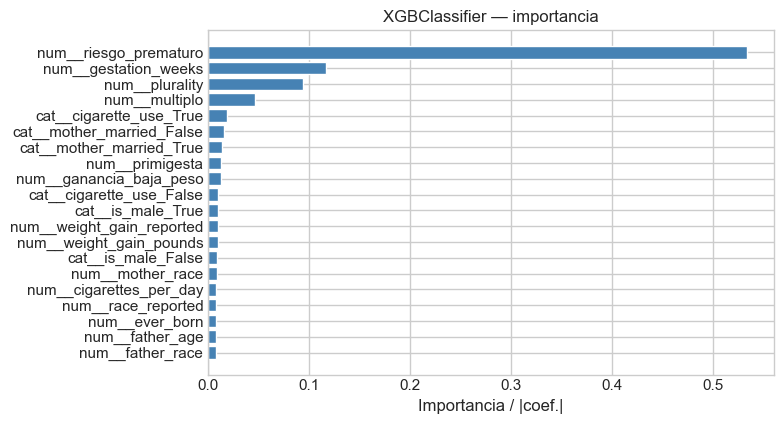

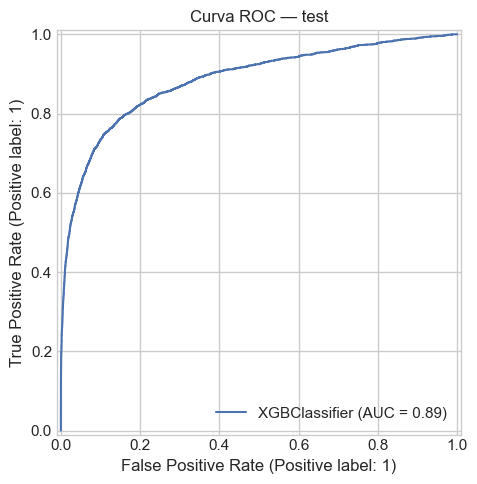

    accuracy  precision  recall     f1  roc_auc  pr_auc         modelo  \
12    0.8887     0.4016  0.8393 0.5433   0.9423  0.7300  XGBClassifier   
13    0.8743     0.3581  0.7485 0.4844   0.8848  0.6024  XGBClassifier   
14    0.8763     0.3626  0.7510 0.4891   0.8859  0.6136  XGBClassifier   

   particion  
12     train  
13       val  
14      test  


In [31]:
name = "XGBClassifier"
if XGBClassifier is None:
    print("xgboost no instalado; se omite.")
else:
    pipe = Pipeline(
        [
            ("prep", clone(prep_tree_c)),
            (
                "model",
                XGBClassifier(
                    n_estimators=150,
                    max_depth=8,
                    learning_rate=0.08,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    tree_method="hist",
                    scale_pos_weight=spw,
                    random_state=RNG,
                    n_jobs=-1,
                    eval_metric="logloss",
                ),
            ),
        ]
    )
    pipe.fit(X_train_c, y_train_c)
    for part, Xp, yp in [
        ("train", X_train_c, y_train_c),
        ("val", X_val_c, y_val_c),
        ("test", X_test_c, y_test_c),
    ]:
        pred = pipe.predict(Xp)
        proba = pipe.predict_proba(Xp)[:, 1]
        m = classification_scores(yp, pred, proba)
        m.update({"modelo": name, "particion": part})
        results_clf.append(m)
    fn = get_feature_names_safe(pipe, Xc.columns)
    imp = pipe.named_steps["model"].feature_importances_
    plot_top_importance(fn[: len(imp)], imp, f"{name} — importancia", top=20)
    plt.tight_layout()
    plt.show()
    fig, ax = plt.subplots(figsize=(6, 5))
    RocCurveDisplay.from_predictions(
        y_test_c, pipe.predict_proba(X_test_c)[:, 1], ax=ax, name=name
    )
    ax.set_title("Curva ROC — test")
    plt.tight_layout()
    plt.show()
    print(pd.DataFrame(results_clf).query("modelo == @name"))


### Modelo 12 — LightGBM (clasificación)

Boosting eficiente; `class_weight='balanced'` o peso por `scale_pos_weight` (aquí usamos el mismo ratio que en XGB).


In [32]:
name = "LGBMClassifier"
if LGBMClassifier is None:
    print("lightgbm no instalado; se omite.")
else:
    pipe = Pipeline(
        [
            ("prep", clone(prep_tree_c)),
            (
                "model",
                LGBMClassifier(
                    n_estimators=200,
                    num_leaves=63,
                    learning_rate=0.05,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    class_weight="balanced",
                    random_state=RNG,
                    n_jobs=-1,
                    verbose=-1,
                ),
            ),
        ]
    )
    pipe.fit(X_train_c, y_train_c)
    for part, Xp, yp in [
        ("train", X_train_c, y_train_c),
        ("val", X_val_c, y_val_c),
        ("test", X_test_c, y_test_c),
    ]:
        pred = pipe.predict(Xp)
        proba = pipe.predict_proba(Xp)[:, 1]
        m = classification_scores(yp, pred, proba)
        m.update({"modelo": name, "particion": part})
        results_clf.append(m)
    fn = get_feature_names_safe(pipe, Xc.columns)
    imp = pipe.named_steps["model"].feature_importances_
    plot_top_importance(fn[: len(imp)], imp, f"{name} — importancia", top=20)
    plt.tight_layout()
    plt.show()
    fig, ax = plt.subplots(figsize=(6, 5))
    RocCurveDisplay.from_predictions(
        y_test_c, pipe.predict_proba(X_test_c)[:, 1], ax=ax, name=name
    )
    ax.set_title("Curva ROC — test")
    plt.tight_layout()
    plt.show()
    print(pd.DataFrame(results_clf).query("modelo == @name"))


lightgbm no instalado; se omite.


## Tablas comparativas (train / validation / test)

Las filas con `particion` **train**, **val** y **test** permiten ver sobreajuste (brecha train vs test) y estabilidad en validación.

### Lectura rápida del cuadro

- **Regresión:** menor RMSE/MAE y mayor R² en **test** indican mejor generalización; si **train** es mucho mejor que **test**, hay sobreajuste.
- **Clasificación:** para bajo peso (clase minoritaria), suelen importar más **recall** y **PR-AUC** que la exactitud global; **ROC-AUC** resume la capacidad de ranking de riesgo.


In [33]:
tab_reg = pd.DataFrame(results_reg)
if len(tab_reg):
    display(
        tab_reg.pivot_table(
            index="modelo", columns="particion", values=["RMSE", "MAE", "R2"]
        )
    )

tab_clf = pd.DataFrame(results_clf)
if len(tab_clf):
    display(
        tab_clf.pivot_table(
            index="modelo",
            columns="particion",
            values=["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"],
        )
    )


MAE                   R2                 RMSE         \
particion               test  train    val   test  train    val   test  train   
modelo                                                                          
ElasticNetCV          0.8012 0.7991 0.8019 0.3711 0.3775 0.3708 1.0328 1.0319   
LinearRegression      0.8012 0.7991 0.8020 0.3712 0.3776 0.3708 1.0327 1.0319   
LinearSVR             0.8008 0.7989 0.8018 0.3710 0.3773 0.3704 1.0328 1.0321   
RandomForestRegressor 0.7709 0.7482 0.7742 0.4126 0.4534 0.4126 0.9981 0.9670   
XGBRegressor          0.7660 0.7329 0.7696 0.4187 0.4772 0.4191 0.9929 0.9458   

                              
particion                val  
modelo                        
ElasticNetCV          1.0338  
LinearRegression      1.0338  
LinearSVR             1.0341  
RandomForestRegressor 0.9989  
XGBRegressor          0.9933

accuracy                   f1               pr_auc  \
particion                  test  train    val   test  train    val   test   
modelo                                                                      
BaggingClassifier        0.8723 0.8755 0.8707 0.4876 0.5020 0.4821 0.6219   
CalibratedLinearSVC      0.9415 0.9415 0.9401 0.5041 0.5122 0.4941 0.6063   
LogisticRegression       0.8863 0.8870 0.8842 0.5074 0.5104 0.5014 0.6090   
RandomForestClassifier   0.8770 0.8804 0.8755 0.4954 0.5092 0.4895 0.6108   
XGBClassifier            0.8763 0.8887 0.8743 0.4891 0.5433 0.4844 0.6136   

                                     precision               recall         \
particion               train    val      test  train    val   test  train   
modelo                                                                       
BaggingClassifier      0.6526 0.6104    0.3566 0.3666 0.3524 0.7708 0.7957   
CalibratedLinearSVC    0.6140 0.5977    0.7598 0.7472 0.7407 0.3772 0.3896   
LogisticRegression     0.6181 0.6013    0.3853 0.3876 0.3796 0.7429 0.7473   
RandomForestClassifier 0.6406 0.5957    0.3661 0.3763 0.3618 0.7662 0.7870   
XGBClassifier          0.7300 0.6024    0.3626 0.4016 0.3581 0.7510 0.8393   

                              roc_auc                
particion                 val    test  train    val  
modelo                                               
BaggingClassifier      0.7629  0.8905 0.9195 0.8876  
CalibratedLinearSVC    0.3707  0.8847 0.8897 0.8855  
LogisticRegression     0.7384  0.8844 0.8899 0.8851  
RandomForestClassifier 0.7566  0.8931 0.9198 0.8895  
XGBClassifier          0.7485  0.8859 0.9423 0.8848

## Referencia breve (qué hace cada familia de modelo)

| Modelo | Idea |
|--------|------|
| **LinearRegression** | Ajuste analítico por mínimos cuadrados en features escaladas. |
| **ElasticNetCV** | Regularización L1+L2 con CV interno para estabilidad y selección suave. |
| **RandomForest** | Muchos árboles independientes; importancia por impureza. |
| **XGBoost / LightGBM** | Boosting secuencial de árboles; muy fuerte en tabular. |
| **LinearSVR** | Tubo ε-insensible + penalización; regresión robusta lineal. |
| **LogisticRegression** | Probabilidades vía logit; `balanced` para la clase minoritaria. |
| **CalibratedLinearSVC** | Hiperplano lineal + calibración para probabilidades y ROC. |
| **Bagging** | Promedio de árboles sobre bootstrap para reducir varianza. |
